# Benchmark Analysis — SPY

This notebook compares the five project stocks with SPY, a broad U.S. equity-market benchmark, using the same historical period and daily-return methodology.

## Objective and limitations

The analysis measures performance relative to SPY, excess return, relative cumulative wealth, annualized volatility differences, and trailing rolling correlations. These are descriptive historical comparisons; they do not provide investment recommendations or imply future outcomes.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.benchmark_analysis import (
    FIGURES_DIR, PROCESSED_DATA_DIR, build_benchmark_comparison, validate_summary
)
from src.benchmark_data import determine_common_period

## Common analysis period and benchmark explanation

In [2]:
start_date, end_date = determine_common_period()
spy_clean = __import__('pandas').read_csv(PROCESSED_DATA_DIR / 'SPY_clean.csv', index_col='Date', parse_dates=['Date'])
print(f'Comparable stock period: {start_date} to {end_date} (download end date is exclusive)')
print(f'SPY observations: {len(spy_clean)}')

Comparable stock period: 2021-08-16 to 2026-08-15 (download end date is exclusive)
SPY observations: 1255


## Stock versus SPY performance

In [3]:
summary, rolling, spy_metrics = build_benchmark_comparison()
validate_summary(summary, spy_metrics)
summary[['Stock', 'Stock Total Return', 'SPY Total Return', 'Excess Total Return', 'Relative Performance']].round(4)

,Stock,Stock Total Return,SPY Total Return,Excess Total Return,Relative Performance
0,AAPL,1.0244,0.7369,0.2875,1.1655
1,MSFT,0.6816,0.7369,-0.0553,0.9682
2,GOOGL,1.5009,0.7369,0.7640,1.4399
3,AMZN,0.5923,0.7369,-0.1446,0.9168
4,NVDA,10.2862,0.7369,9.5493,6.4979


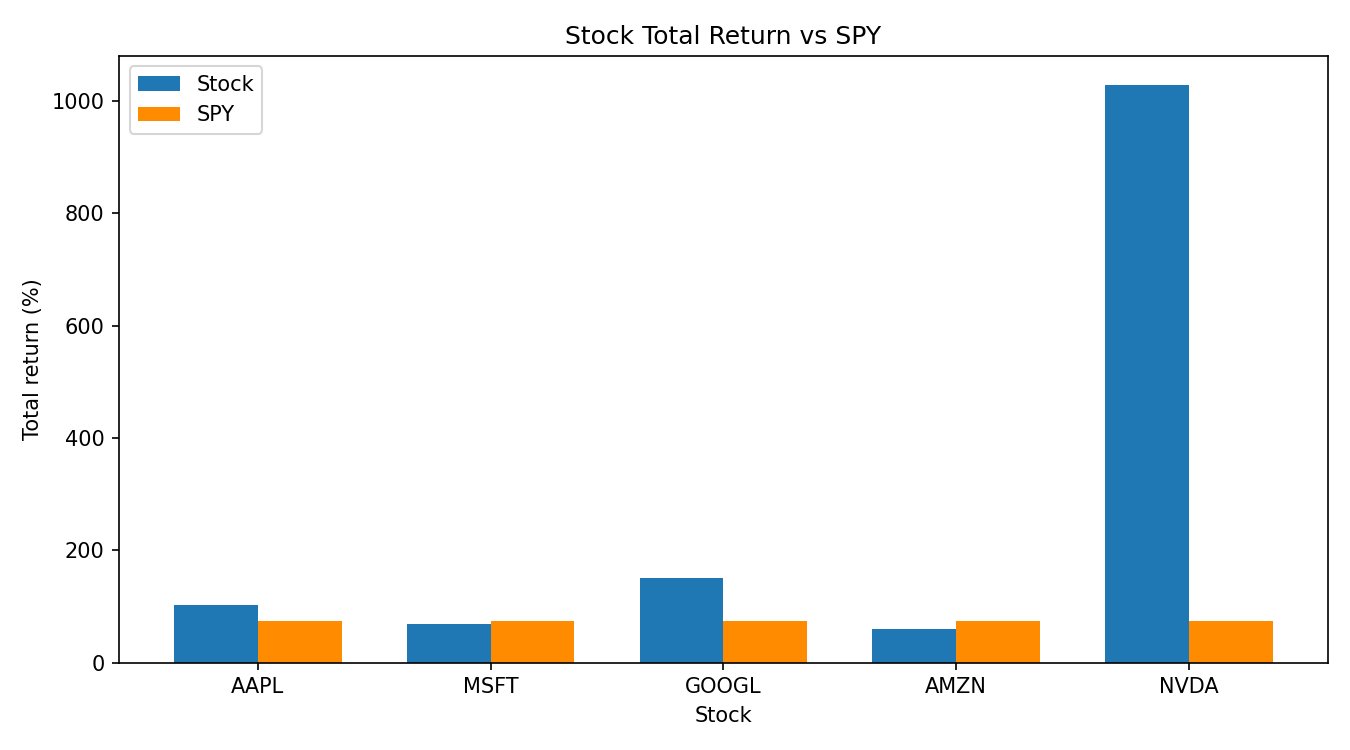

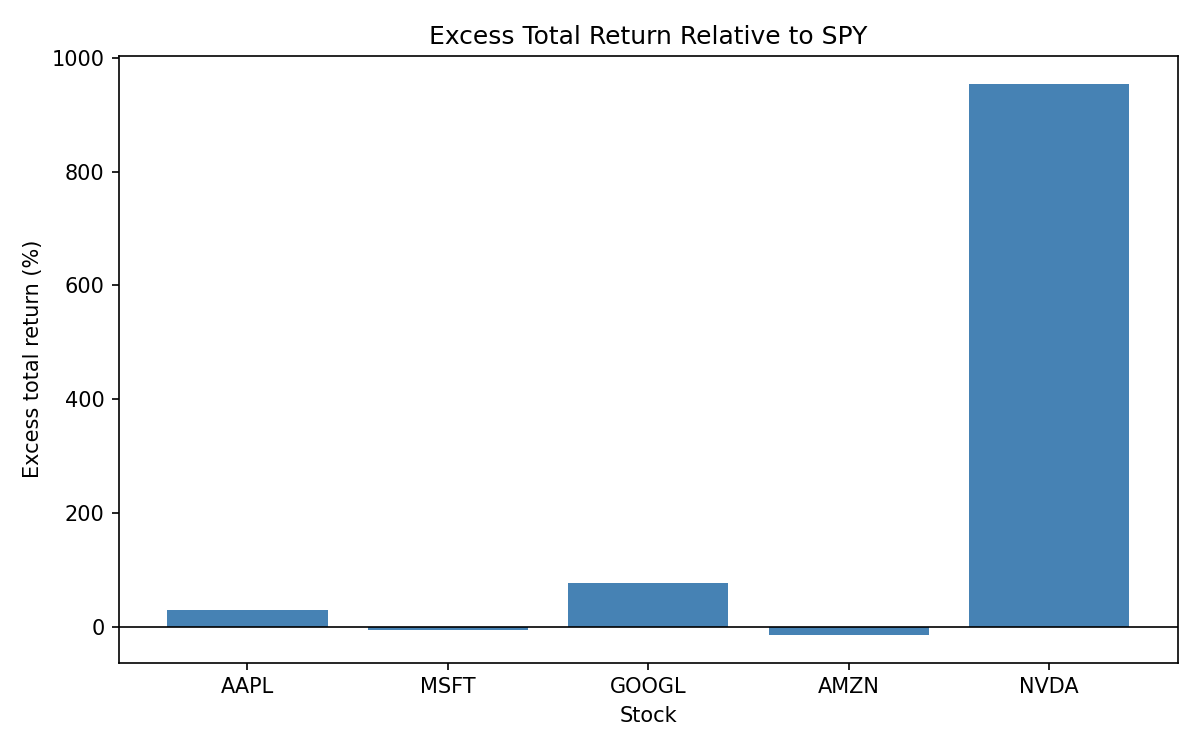

In [4]:
display(Image(filename=str(FIGURES_DIR / 'benchmark_performance_comparison.png')))
display(Image(filename=str(FIGURES_DIR / 'benchmark_excess_return.png')))

Definitions:

- Excess Total Return = Stock Total Return − SPY Total Return
- Relative Performance = (1 + Stock Total Return) / (1 + SPY Total Return)

## Stock versus SPY volatility

In [5]:
summary[['Stock', 'Stock Annualized Volatility', 'SPY Annualized Volatility', 'Volatility Difference', 'Volatility Ratio']].round(4)

,Stock,Stock Annualized Volatility,SPY Annualized Volatility,Volatility Difference,Volatility Ratio
0,AAPL,0.2804,0.1725,0.1079,1.6258
1,MSFT,0.2815,0.1725,0.1090,1.6318
2,GOOGL,0.3212,0.1725,0.1487,1.8622
3,AMZN,0.3639,0.1725,0.1914,2.1097
4,NVDA,0.5194,0.1725,0.3469,3.0111


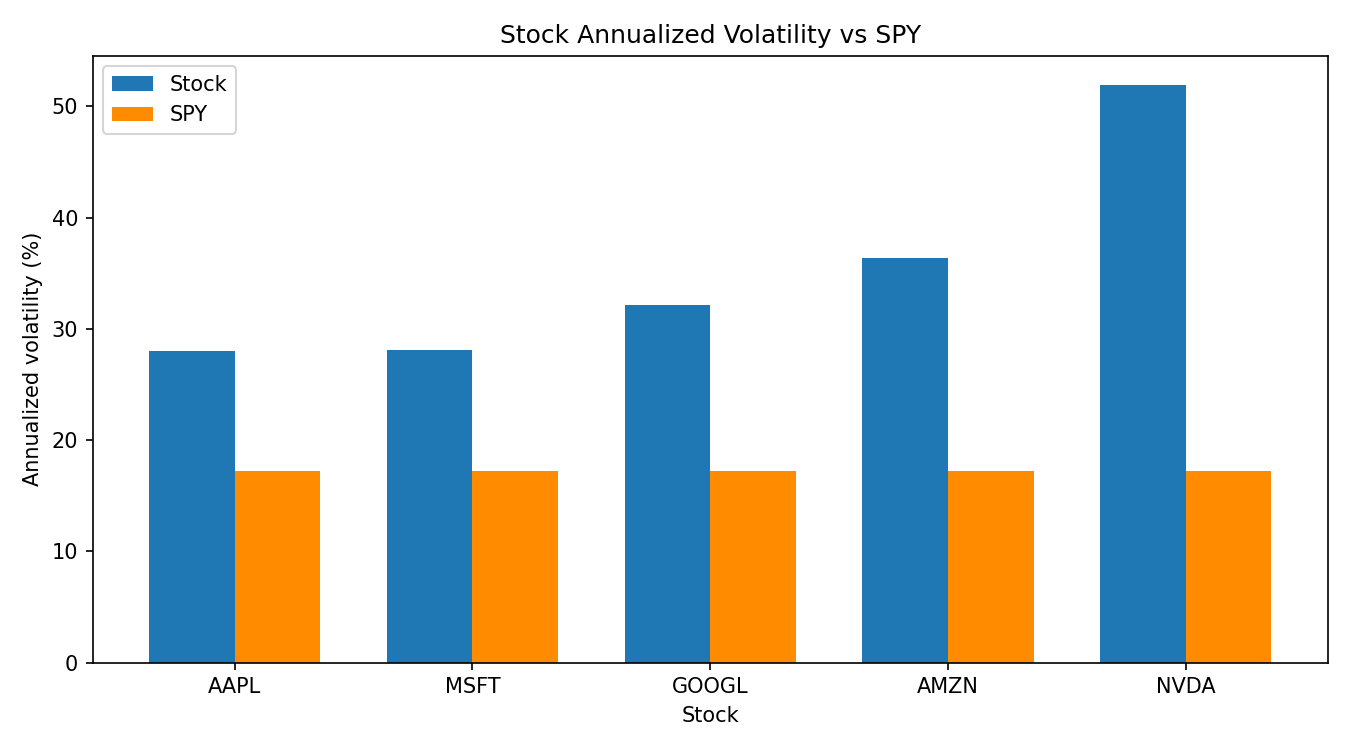

In [6]:
display(Image(filename=str(FIGURES_DIR / 'benchmark_volatility_comparison.png')))

Volatility uses sample standard deviation of daily returns annualized by √252. Volatility Difference = Stock Volatility − SPY Volatility. Volatility Ratio = Stock Volatility / SPY Volatility.

## 60-day rolling correlation with SPY

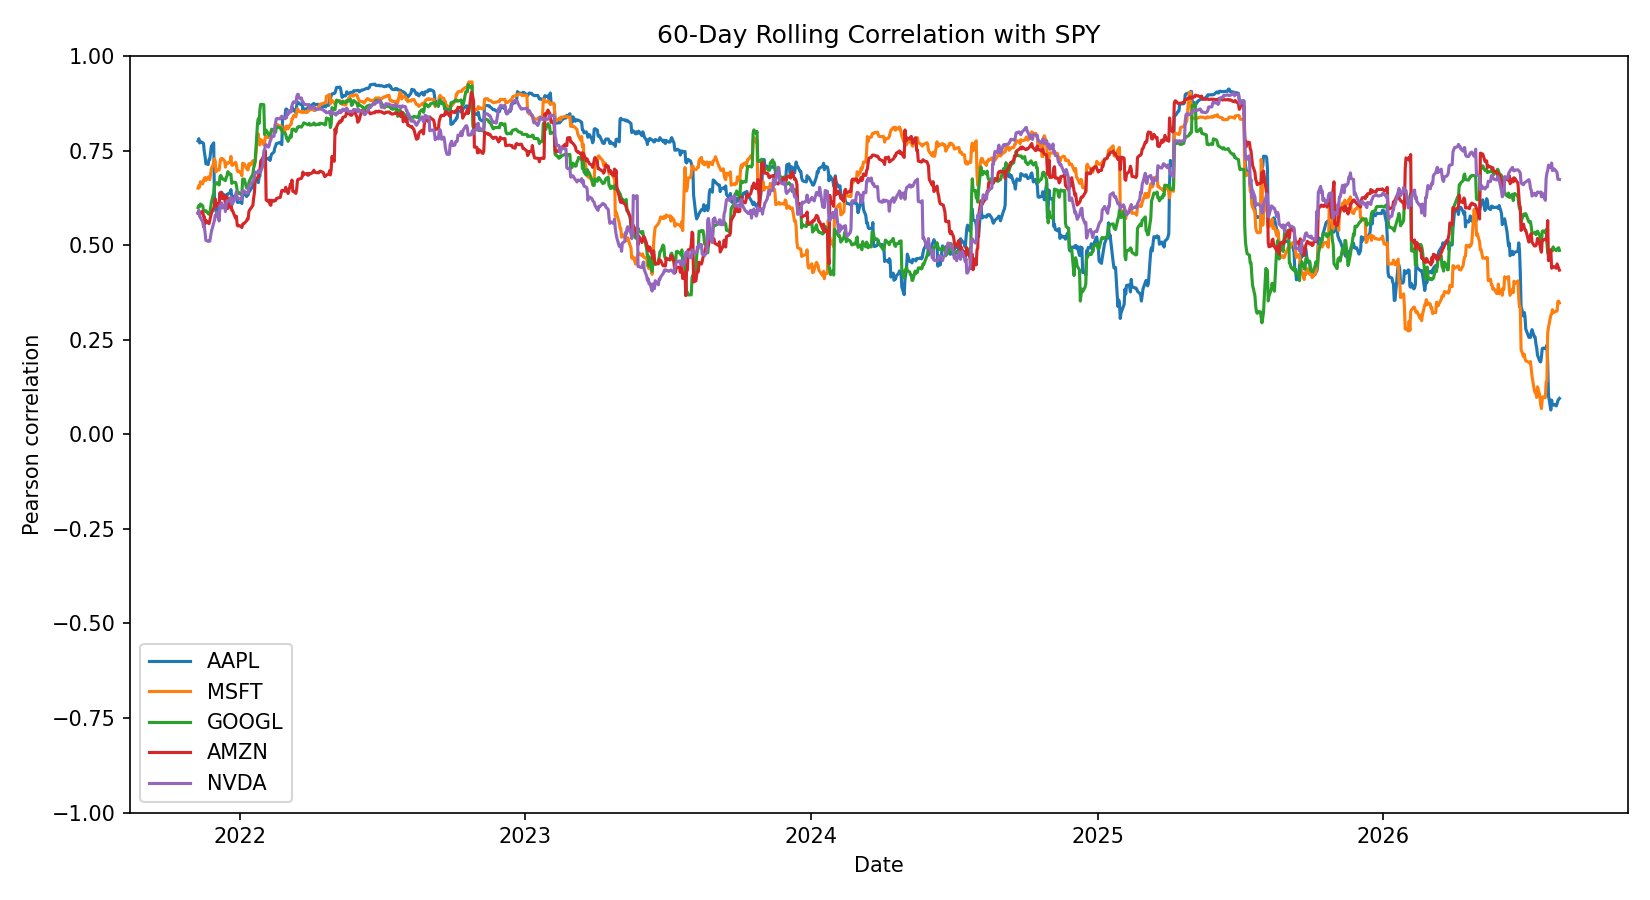

In [7]:
rolling.tail(1).T.rename(columns={rolling.index[-1]: 'Latest Rolling Correlation'})
display(Image(filename=str(FIGURES_DIR / 'benchmark_rolling_correlation.png')))

## Benchmark comparison table

In [8]:
summary.round(4)

,Stock,Stock Total Return,SPY Total Return,Excess Total Return,Relative Performance,Stock Annualized Volatility,SPY Annualized Volatility,Volatility Difference,Volatility Ratio,Latest Rolling Correlation with SPY
0,AAPL,1.0244,0.7369,0.2875,1.1655,0.2804,0.1725,0.1079,1.6258,0.0949
1,MSFT,0.6816,0.7369,-0.0553,0.9682,0.2815,0.1725,0.1090,1.6318,0.3473
2,GOOGL,1.5009,0.7369,0.7640,1.4399,0.3212,0.1725,0.1487,1.8622,0.4860
3,AMZN,0.5923,0.7369,-0.1446,0.9168,0.3639,0.1725,0.1914,2.1097,0.4339
4,NVDA,10.2862,0.7369,9.5493,6.4979,0.5194,0.1725,0.3469,3.0111,0.6736


## Key observations

In [9]:
highest_return = summary.loc[summary['Stock Total Return'].idxmax()]
lowest_return = summary.loc[summary['Stock Total Return'].idxmin()]
highest_volatility = summary.loc[summary['Stock Annualized Volatility'].idxmax()]
lowest_volatility = summary.loc[summary['Stock Annualized Volatility'].idxmin()]
print(f"{highest_return['Stock']} had the highest total return relative to the benchmark period.")
print(f"{lowest_return['Stock']} had the lowest total return relative to the benchmark period.")
print(f"{highest_volatility['Stock']} had the highest annualized volatility; {lowest_volatility['Stock']} had the lowest.")
for ticker in summary['Stock']:
    relation = 'exceeded' if summary.loc[summary.Stock == ticker, 'Excess Total Return'].iloc[0] > 0 else 'was below'
    print(f"{ticker} total return {relation} SPY over the analyzed period.")

NVDA had the highest total return relative to the benchmark period.
AMZN had the lowest total return relative to the benchmark period.
NVDA had the highest annualized volatility; AAPL had the lowest.
AAPL total return exceeded SPY over the analyzed period.
MSFT total return was below SPY over the analyzed period.
GOOGL total return exceeded SPY over the analyzed period.
AMZN total return was below SPY over the analyzed period.
NVDA total return exceeded SPY over the analyzed period.


## Conclusion

The benchmark comparison shows how historical total returns and volatility differed from SPY and how each stock's return relationship with SPY changed over time. Historical relationships may change, correlation does not imply causation, and this analysis is descriptive rather than predictive. No investment recommendation is made.